# Text Summarization with NLP


In [13]:
!wget https://raw.githubusercontent.com/umerkang66/ai-ml-dl/refs/heads/master/tensorflow-bootcamp/03-computer-vision-tf/helper_functions.py


--2026-08-22 20:49:36--  https://raw.githubusercontent.com/umerkang66/ai-ml-dl/refs/heads/master/tensorflow-bootcamp/03-computer-vision-tf/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10836 (11K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.58K  --.-KB/s    in 0s      

2026-08-22 20:49:36 (116 MB/s) - ‘helper_functions.py’ saved [10836/10836]



In [14]:
from helper_functions import (
    unzip_data,
    plot_loss_curves,
    compare_historys,
)

## SAMSum Text Summarization Dataset


In [ ]:
!pip install -q datasets transformers torch rouge-score


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


from datasets import load_dataset

raw_dataset = load_dataset("knkarthick/samsum")
train_df = (
    pd.DataFrame(raw_dataset["train"])[["dialogue", "summary"]]
    .sample(n=1200, random_state=42)
    .reset_index(drop=True)
)
val_df = (
    pd.DataFrame(raw_dataset["validation"])[["dialogue", "summary"]]
    .sample(n=300, random_state=42)
    .reset_index(drop=True)
)
test_df = (
    pd.DataFrame(raw_dataset["test"])[["dialogue", "summary"]]
    .sample(n=300, random_state=42)
    .reset_index(drop=True)
)

## Read the Data


In [16]:
train_df.head()

,dialogue,summary
0,Violet: hi! i came across this Austin's articl...,Violet sent Claire Austin's article.
1,"Mel: Right, it's time I bought some Christmas ...",Mel bought Christmas presents while Evie keeps...
2,Carol: Can you pls pick up when I call you.\nC...,"Fiona can't talk to Carol, because she's very ..."
3,"Adam: Do u have a map of Paris?\nTom: Yes, Why...",Tom has a map of Paris.
4,"Frank: Hi, how's the family?\nMike: great! Sam...","Mike is happy, because Sam's moved out. Mike a..."


In [17]:
val_df.head()

,dialogue,summary
0,"Edd: wow, did you hear that they're transferri...",Rose and Edd will be transferred to a new depa...
1,"Tom: Where is the ""Sala del Capitolo""\nKevin: ...","""Sala del Capitolo"" Tom is looking for is in t..."
2,Patricia: The rowing practice is cancelled!\nK...,The rowing practice is cancelled. A few member...
3,"Tom: U OK?\nAlex: Yeah, pretty good. U?\nTom: ...",Tom and Alex had fun last night. They drank a ...
4,"Patricia: Hello, here's the fair-trade brand I...",Patricia recommends a fair-trade brand she tal...


In [18]:
test_df.head()

,dialogue,summary
0,Olafur: are we doing anything for New Year's E...,"Nathalie, Olafur and Zoe are planning the New ..."
1,Javier: Hey do you know any tattoo parlors ove...,Javier was initially eager to have a tatoo don...
2,"Martha: Hey, can I ask you a question?\nOpheli...",Martha likes Ophelia's lenses and wants to buy...
3,"Miranda: Hi S, could we cancel tomorrow's meet...",Miranda can't make her meeting with Stephanie ...
4,Sam: Where are you?\nKate: downstairs\nSam: al...,Kate and Jeff are downstairs in a room next to...


In [19]:
len(train_df), len(val_df), len(test_df)

(1200, 300, 300)

## Let's visualize some random samples


In [30]:
import random

random_index = random.randint(0, len(train_df) - 1)

for _, row in train_df.iloc[random_index : random_index + 1].iterrows():
    print(f"Dialogue:\n{row['dialogue']}\n")
    print(f"Summary:\n{row['summary']}\n")

Dialogue:
Ana: hi mum, could you send me the name of the ophtalmologist?
Mum: another headache?
Ana: yes, i'd like to know what to do when it's an ophtamic headache!
Mum: like any others, with paracetamol i guess.
Ana: i can't see my neighbour on my right... that's terrible!
Mum: are you stressed? because you're in the train? you're leaving you mum? you spent an hour in a creepy coffee?
Ana: no i'm not.  But i'm quite upset with that headache
Mum: have a good time in Paris. 
Ana: thanks mum. I'm in the tube.
Mum: where does she live?
Ana: Sèvres i think!
Mum: hope you're sure! is there any metro?
Ana: yep and bus too
Mum: nice trip
Ana: are you already in the train?
Mum: yes that's our turn. Do you see you neighbours now?
Ana: yes i'm feeling much better. See you next year!
Mum: ah ah.. ok see you tomorrow. Have a nice evening
Ana: we're going to the Champs Elysées
Mum: be carefull, it's gonna be crowded tonight. Better stay away from the crowd.
Ana: we'll be safe don't worry. we'll go

## Converting text into numbers


In [31]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

In [32]:
average_dialogue_length = round(
    sum([len(i.split()) for i in train_df["dialogue"]]) / len(train_df)
)
average_summary_length = round(
    sum([len(i.split()) for i in train_df["summary"]]) / len(train_df)
)

print(f"Average dialogue length: {average_dialogue_length} words")
print(f"Average summary length: {average_summary_length} words")

Average dialogue length: 93 words
Average summary length: 20 words


In [ ]:
# Set sequence length budgets
max_input_length = min(average_dialogue_length * 2, 100)
max_target_length = min(average_summary_length * 2, 30)

# Encoder Text Vectorizer (for dialogues)
dialogue_vectorizer = TextVectorization(
    max_tokens=10000,  # larger vocab size for dialogues
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=max_input_length,
    pad_to_max_tokens=True,
)

# Decoder Text Vectorizer (for summaries)
summary_vectorizer = TextVectorization(
    max_tokens=5000,  # smaller vocab size for summaries
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=max_target_length,
    pad_to_max_tokens=True,
)

In [34]:
# Fit the text vectorizers to the training text
dialogue_vectorizer.adapt(train_df["dialogue"])
summary_vectorizer.adapt(train_df["summary"])

In [36]:
# Create a sample text and pass it through dialogue vectorizer
sample_dialogue = "Hey, i am learning NLP!"

dialogue_vectorizer([sample_dialogue])

<tf.Tensor: shape=(1, 100), dtype=int64, numpy=
array([[  93,    2,   95, 2123,    1,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0]])>

In [37]:
# Get vocabulary properties
dialogue_vocab = dialogue_vectorizer.get_vocabulary()
summary_vocab = summary_vectorizer.get_vocabulary()

print("Top 5 dialogue words: ", dialogue_vocab[:5])
print("Dialogue vocabulary size: ", len(dialogue_vocab))
print("Top 5 summary words: ", summary_vocab[:5])
print("Summary vocabulary size: ", len(summary_vocab))

Top 5 dialogue words:  ['', '[UNK]', np.str_('i'), np.str_('you'), np.str_('the')]
Dialogue vocabulary size:  8589
Top 5 summary words:  ['', '[UNK]', np.str_('to'), np.str_('and'), np.str_('the')]
Summary vocabulary size:  4454


In [38]:
from tensorflow.keras.layers import Embedding

encoder_embedding = Embedding(
    input_dim=len(dialogue_vocab),
    output_dim=128,
    input_length=max_input_length,
    name="encoder_embedding",
)

decoder_embedding = Embedding(
    input_dim=len(summary_vocab),
    output_dim=128,
    input_length=max_target_length,
    name="decoder_embedding",
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [40]:
sample_vec = dialogue_vectorizer([sample_dialogue])
sample_embed = encoder_embedding(sample_vec)
sample_embed[0][0], sample_embed[0][0].shape, sample_embed.shape

(<tf.Tensor: shape=(128,), dtype=float32, numpy=
 array([ 0.01066184, -0.01362884,  0.03044191,  0.01312944,  0.04042539,
        -0.03254675,  0.0204934 , -0.00263784, -0.02243938, -0.04761953,
         0.01098869, -0.01699964, -0.03077685, -0.04365195, -0.03241795,
        -0.01982148,  0.0006879 ,  0.00778282, -0.03352453, -0.03384714,
         0.04904502,  0.01521773,  0.0384676 , -0.0459004 , -0.01020996,
         0.03401868,  0.04083974, -0.03793203, -0.01954335,  0.00601006,
        -0.03517741,  0.03537694,  0.0358857 ,  0.04444367,  0.01312382,
         0.04712323,  0.0067532 , -0.01709251,  0.02363053, -0.01043491,
        -0.04194013,  0.04849811, -0.0007528 , -0.0296979 ,  0.0172569 ,
        -0.01220473, -0.01964526, -0.04086521, -0.03715429, -0.00433569,
         0.01063498, -0.0175439 , -0.0378745 , -0.01978268, -0.03354038,
        -0.00577228,  0.02924783,  0.04394292, -0.04409096, -0.01265078,
         0.01654396,  0.01037893, -0.00992688,  0.01278711,  0.03070946,
  

## Evaluation Metric: ROUGE Score


In [43]:
from collections import Counter
import numpy as np


def calculate_rouge_scores(predictions, references):
    def get_ngrams(text, n):
        tokens = str(text).lower().split()
        return [tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)]

    def lcs(seq1, seq2):
        m, n = len(seq1), len(seq2)
        if m == 0 or n == 0:
            return 0
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if seq1[i - 1] == seq2[j - 1]:
                    dp[i][j] = dp[i - 1][j - 1] + 1
                else:
                    dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
        return dp[m][n]

    r1_list, r2_list, rl_list = [], [], []

    for pred, ref in zip(predictions, references):
        pred_tokens = str(pred).lower().split()
        ref_tokens = str(ref).lower().split()

        if not pred_tokens or not ref_tokens:
            r1_list.append(0.0)
            r2_list.append(0.0)
            rl_list.append(0.0)
            continue

        # ROUGE-1
        pred_1 = Counter(get_ngrams(pred, 1))
        ref_1 = Counter(get_ngrams(ref, 1))
        overlap_1 = sum((pred_1 & ref_1).values())
        p1 = overlap_1 / len(pred_tokens) if pred_tokens else 0
        r1 = overlap_1 / len(ref_tokens) if ref_tokens else 0
        f1_1 = (2 * p1 * r1 / (p1 + r1)) if (p1 + r1) > 0 else 0
        r1_list.append(f1_1)

        # ROUGE-2
        pred_2 = Counter(get_ngrams(pred, 2))
        ref_2 = Counter(get_ngrams(ref, 2))
        overlap_2 = sum((pred_2 & ref_2).values())
        p2 = overlap_2 / max(len(pred_tokens) - 1, 1)
        r2 = overlap_2 / max(len(ref_tokens) - 1, 1)
        f1_2 = (2 * p2 * r2 / (p2 + r2)) if (p2 + r2) > 0 else 0
        r2_list.append(f1_2)

        # ROUGE-L
        lcs_len = lcs(pred_tokens, ref_tokens)
        pl = lcs_len / len(pred_tokens) if pred_tokens else 0
        rl = lcs_len / len(ref_tokens) if ref_tokens else 0
        f1_l = (2 * pl * rl / (pl + rl)) if (pl + rl) > 0 else 0
        rl_list.append(f1_l)

    return {
        "rouge1": round(float(np.mean(r1_list)) * 100, 2),
        "rouge2": round(float(np.mean(r2_list)) * 100, 2),
        "rougeL": round(float(np.mean(rl_list)) * 100, 2),
    }

## Experiment Models

- Model 0: Lead-N Extractive Baseline
- Model 1: Sequence-to-Sequence with LSTM (Encoder-Decoder)
- Model 2: Sequence-to-Sequence with GRU (Encoder-Decoder)
- Model 3: Sequence-to-Sequence with Bidirectional LSTM (Encoder-Decoder)
- Model 4: Sequence-to-Sequence with Additive Attention Mechanism
- Model 5: Transfer Learning (Pretrained Transformer - Hugging Face DistilBART)


## MODEL_0: BaseLine Lead-N Extractive Summarizer


In [41]:
# Lead-N Extractive Baseline: extracts the first meaningful lines from the dialogue
def lead_n_baseline_summarizer(dialogue, n=2):
    lines = [line.strip() for line in dialogue.split("\n") if line.strip()]
    cleaned_lines = []
    for line in lines:
        if ":" in line:
            cleaned_lines.append(line.split(":", 1)[1].strip())
        else:
            cleaned_lines.append(line)
    return " ".join(cleaned_lines[:n]) if cleaned_lines else dialogue


# Make predictions
baseline_preds = [lead_n_baseline_summarizer(text, n=2) for text in val_df["dialogue"]]

In [44]:
# Calculate baseline results
baseline_results = calculate_rouge_scores(
    predictions=baseline_preds, references=val_df["summary"]
)
baseline_results

{'rouge1': 15.26, 'rouge2': 5.96, 'rougeL': 13.77}

## Preparing Data for Seq2Seq Models


In [45]:
# Turn text into numerical arrays for Encoder-Decoder models
train_decoder_targets = summary_vectorizer(train_df["summary"].to_numpy())
val_decoder_targets = summary_vectorizer(val_df["summary"].to_numpy())

# Helper function to convert predicted token IDs back to words
vocab_array = np.array(summary_vocab)


def decode_predictions(pred_token_ids):
    summaries = []
    for seq in pred_token_ids:
        words = [vocab_array[idx] for idx in seq if 1 < idx < len(vocab_array)]
        summaries.append(" ".join(words))
    return summaries

## MODEL_1: Seq2Seq with LSTM


In [46]:
from tensorflow.keras.layers import Dense, Input, LSTM, RepeatVector
from tensorflow.keras.models import Model

# Encoder
encoder_inputs = Input(shape=(1,), dtype=tf.string, name="encoder_input_lstm")
x = dialogue_vectorizer(encoder_inputs)
x = encoder_embedding(x)
_, state_h, state_c = LSTM(64, return_state=True, name="encoder_lstm")(x)
encoder_states = [state_h, state_c]

# Decoder
repeated_state = RepeatVector(max_target_length)(state_h)
decoder_out = LSTM(64, return_sequences=True, name="decoder_lstm")(
    repeated_state, initial_state=encoder_states
)
decoder_outputs = Dense(
    len(summary_vocab), activation="softmax", name="output_layer_lstm"
)(decoder_out)

# Build Model 1
model_1 = Model(encoder_inputs, decoder_outputs, name="model_1_seq2seq_lstm")

In [47]:
model_1.summary()

Model: "model_1_seq2seq_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input_lstm  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 100)       │          0 │ encoder_input_ls… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 100, 128)  │  1,099,392 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     49,408 │ encoder_embeddin… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 30, 64)    │          0 │ encoder_lstm[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 30, 64)    │     33,024 │ repeat_vector[0]… │
│                     │                   │            │ encoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer_lstm   │ (None, 30, 4454)  │    289,510 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,471,334 (5.61 MB)

 Trainable params: 1,471,334 (5.61 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Compile model
model_1.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# Fit model
model_1_history = model_1.fit(
    train_df["dialogue"].to_numpy(),
    train_decoder_targets,
    epochs=5,
    validation_data=(val_df["dialogue"].to_numpy(), val_decoder_targets),
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.3724 - loss: 7.3327 - val_accuracy: 0.3817 - val_loss: 5.7866
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3834 - loss: 5.1359 - val_accuracy: 0.3817 - val_loss: 4.7853
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3834 - loss: 4.6579 - val_accuracy: 0.3817 - val_loss: 4.6878
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3834 - loss: 4.5595 - val_accuracy: 0.3817 - val_loss: 4.6239
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3834 - loss: 4.4910 - val_accuracy: 0.3817 - val_loss: 4.6133


In [49]:
# Make predictions on the validation set
model_1_pred_probs = model_1.predict(val_df["dialogue"].to_numpy())
model_1_pred_ids = np.argmax(model_1_pred_probs, axis=-1)
model_1_preds = decode_predictions(model_1_pred_ids)

# Calculate Model 1 results
model_1_results = calculate_rouge_scores(
    predictions=model_1_preds, references=val_df["summary"]
)
model_1_results

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


{'rouge1': 4.07, 'rouge2': 0.0, 'rougeL': 4.07}

## MODEL2: Seq2Seq with GRU


In [50]:
from tensorflow.keras.layers import Dense, GRU, Input, RepeatVector
from tensorflow.keras.models import Model

# Encoder
encoder_inputs = Input(shape=(1,), dtype=tf.string, name="encoder_input_gru")
x = dialogue_vectorizer(encoder_inputs)
x = encoder_embedding(x)
_, state_h = GRU(64, return_state=True, name="encoder_gru")(x)

# Decoder
repeated_state = RepeatVector(max_target_length)(state_h)
decoder_out = GRU(64, return_sequences=True, name="decoder_gru")(
    repeated_state, initial_state=state_h
)
decoder_outputs = Dense(
    len(summary_vocab), activation="softmax", name="output_layer_gru"
)(decoder_out)

# Build Model 2
model_2 = Model(encoder_inputs, decoder_outputs, name="model_2_seq2seq_gru")

In [51]:
# Compile model
model_2.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# Fit model
model_2_history = model_2.fit(
    train_df["dialogue"].to_numpy(),
    train_decoder_targets,
    epochs=5,
    validation_data=(val_df["dialogue"].to_numpy(), val_decoder_targets),
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.3732 - loss: 7.1710 - val_accuracy: 0.3817 - val_loss: 5.8011
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3834 - loss: 5.1567 - val_accuracy: 0.3817 - val_loss: 4.8496
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3834 - loss: 4.6854 - val_accuracy: 0.3817 - val_loss: 4.7367
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3834 - loss: 4.5862 - val_accuracy: 0.3817 - val_loss: 4.6675
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3834 - loss: 4.5137 - val_accuracy: 0.3817 - val_loss: 4.6319


In [52]:
# Make predictions on the validation set
model_2_pred_probs = model_2.predict(val_df["dialogue"].to_numpy())
model_2_pred_ids = np.argmax(model_2_pred_probs, axis=-1)
model_2_preds = decode_predictions(model_2_pred_ids)

# Calculate Model 2 results
model_2_results = calculate_rouge_scores(
    predictions=model_2_preds, references=val_df["summary"]
)
model_2_results

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


{'rouge1': 5.72, 'rouge2': 0.0, 'rougeL': 5.72}

## MODEL3: Seq2Seq with Bidirectional LSTM


In [53]:
from tensorflow.keras.layers import (
    Bidirectional,
    Concatenate,
    Dense,
    Input,
    LSTM,
    RepeatVector,
)
from tensorflow.keras.models import Model

# Encoder
encoder_inputs = Input(shape=(1,), dtype=tf.string, name="encoder_input_bilstm")
x = dialogue_vectorizer(encoder_inputs)
x = encoder_embedding(x)
_, forward_h, forward_c, backward_h, backward_c = Bidirectional(
    LSTM(32, return_state=True, name="encoder_bilstm")
)(x)

# Concatenate forward and backward hidden and cell states
state_h = Concatenate()([forward_h, backward_h])
state_c = Concatenate()([forward_c, backward_c])
encoder_states = [state_h, state_c]

# Decoder
repeated_state = RepeatVector(max_target_length)(state_h)
decoder_out = LSTM(64, return_sequences=True, name="decoder_lstm_bi")(
    repeated_state, initial_state=encoder_states
)
decoder_outputs = Dense(
    len(summary_vocab), activation="softmax", name="output_layer_bi"
)(decoder_out)

# Build Model 3
model_3 = Model(encoder_inputs, decoder_outputs, name="model_3_bilstm")

In [54]:
# Compile model
model_3.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# Fit model
model_3_history = model_3.fit(
    train_df["dialogue"].to_numpy(),
    train_decoder_targets,
    epochs=5,
    validation_data=(val_df["dialogue"].to_numpy(), val_decoder_targets),
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.3565 - loss: 7.3840 - val_accuracy: 0.3817 - val_loss: 5.8880
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3834 - loss: 5.1567 - val_accuracy: 0.3817 - val_loss: 4.8120
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3834 - loss: 4.6290 - val_accuracy: 0.3817 - val_loss: 4.6594
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3834 - loss: 4.5090 - val_accuracy: 0.3817 - val_loss: 4.6169
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3834 - loss: 4.4368 - val_accuracy: 0.3817 - val_loss: 4.6079


In [55]:
# Make predictions on the validation set
model_3_pred_probs = model_3.predict(val_df["dialogue"].to_numpy())
model_3_pred_ids = np.argmax(model_3_pred_probs, axis=-1)
model_3_preds = decode_predictions(model_3_pred_ids)

# Calculate Model 3 results
model_3_results = calculate_rouge_scores(
    predictions=model_3_preds, references=val_df["summary"]
)
model_3_results

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


{'rouge1': 4.07, 'rouge2': 0.0, 'rougeL': 4.07}

## MODEL4: Seq2Seq with Additive Attention Mechanism


In [56]:
from tensorflow.keras.layers import (
    AdditiveAttention,
    Concatenate,
    Dense,
    Input,
    LSTM,
    RepeatVector,
)
from tensorflow.keras.models import Model

# Encoder
encoder_inputs = Input(shape=(1,), dtype=tf.string, name="encoder_input_attn")
x = dialogue_vectorizer(encoder_inputs)
x = encoder_embedding(x)
encoder_seq, state_h, state_c = LSTM(
    64, return_sequences=True, return_state=True, name="encoder_lstm_attn"
)(x)
encoder_states = [state_h, state_c]

# Decoder
repeated_state = RepeatVector(max_target_length)(state_h)
decoder_seq = LSTM(64, return_sequences=True, name="decoder_lstm_attn")(
    repeated_state, initial_state=encoder_states
)

# Additive (Bahdanau) Attention Layer
context_vector = AdditiveAttention(name="bahdanau_attention")(
    [decoder_seq, encoder_seq]
)
decoder_combined = Concatenate(name="concat_layer")([decoder_seq, context_vector])

decoder_outputs = Dense(
    len(summary_vocab), activation="softmax", name="output_layer_attn"
)(decoder_combined)

# Build Model 4
model_4 = Model(encoder_inputs, decoder_outputs, name="model_4_seq2seq_attention")

In [57]:
# Compile model
model_4.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# Fit model
model_4_history = model_4.fit(
    train_df["dialogue"].to_numpy(),
    train_decoder_targets,
    epochs=5,
    validation_data=(val_df["dialogue"].to_numpy(), val_decoder_targets),
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.3640 - loss: 6.5342 - val_accuracy: 0.3817 - val_loss: 4.7676
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3834 - loss: 4.6201 - val_accuracy: 0.3817 - val_loss: 4.6117
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3875 - loss: 4.4782 - val_accuracy: 0.3890 - val_loss: 4.6016
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3900 - loss: 4.4340 - val_accuracy: 0.3900 - val_loss: 4.6063
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3925 - loss: 4.3961 - val_accuracy: 0.3918 - val_loss: 4.6086


In [58]:
# Make predictions on the validation set
model_4_pred_probs = model_4.predict(val_df["dialogue"].to_numpy())
model_4_pred_ids = np.argmax(model_4_pred_probs, axis=-1)
model_4_preds = decode_predictions(model_4_pred_ids)

# Calculate Model 4 results
model_4_results = calculate_rouge_scores(
    predictions=model_4_preds, references=val_df["summary"]
)
model_4_results

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


{'rouge1': 11.29, 'rouge2': 0.0, 'rougeL': 10.16}

## MODEL5: Transfer Learning (Pretrained Transformer - Hugging Face DistilBART with PyTorch)

**DistilBART** (`sshleifer/distilbart-cnn-12-6`) from Hugging Face using **PyTorch (`torch`)**.


In [59]:
# Import PyTorch and Hugging Face Transformers
import numpy as np
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# Device configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pretrained DistilBART tokenizer and model
checkpoint = "sshleifer/distilbart-cnn-12-6"
hf_tokenizer = AutoTokenizer.from_pretrained(checkpoint)
hf_model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint).to(device)
hf_model.eval()

Using device: cuda


config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.22GB            

model.safetensors: downloading bytes:           |  0.00B            

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        

In [60]:
# Inspect a sample tokenized dialogue and generated summary
sample_text = train_df["dialogue"].iloc[0]
inputs = hf_tokenizer(
    sample_text, max_length=512, truncation=True, return_tensors="pt"
).to(device)

with torch.no_grad():
    summary_ids = hf_model.generate(
        inputs["input_ids"],
        max_length=60,
        min_length=10,
        num_beams=4,
        length_penalty=2.0,
        early_stopping=True,
    )

sample_summary = hf_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
print(f"Original Dialogue:\n{sample_text}\n")
print(f"Generated Summary:\n{sample_summary}\n")
print(f"Ground Truth Summary:\n{train_df['summary'].iloc[0]}")

Original Dialogue:
Violet: hi! i came across this Austin's article and i thought that you might find it interesting
Violet: <file_other>
Claire: Hi! :) Thanks, but I've already read it. :)
Claire: But thanks for thinking about me :)

Generated Summary:
 Violet: Hi! i came across this Austin's article and i thought that you might find it interesting . Violet: Thanks, but I've already read it. :)

Ground Truth Summary:
Violet sent Claire Austin's article.


In [61]:
# Helper function to generate summaries in batches using Hugging Face model
def generate_hf_summaries(dialogues, batch_size=16):
    hf_model.eval()
    generated_summaries = []
    for i in range(0, len(dialogues), batch_size):
        batch_texts = list(dialogues[i : i + batch_size])
        inputs = hf_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt",
        ).to(device)

        with torch.no_grad():
            summary_ids = hf_model.generate(
                inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_length=60,
                min_length=10,
                num_beams=4,
                length_penalty=2.0,
                early_stopping=True,
            )

        summaries = [
            hf_tokenizer.decode(g, skip_special_tokens=True) for g in summary_ids
        ]
        generated_summaries.extend(summaries)
    return generated_summaries

In [62]:
# Generate predictions on validation set (evaluating on a representative subset for speed)
val_sample_dialogues = val_df["dialogue"].tolist()[:100]
val_sample_references = val_df["summary"].tolist()[:100]

model_5_preds = generate_hf_summaries(val_sample_dialogues, batch_size=16)

# Calculate Model 5 results
model_5_results = calculate_rouge_scores(
    predictions=model_5_preds, references=val_sample_references
)
model_5_results

{'rouge1': 22.38, 'rouge2': 8.98, 'rougeL': 17.65}

## Comparing the Performance of Each Model


In [63]:
# Combine all model results into a DataFrame
all_model_results = pd.DataFrame(
    {
        "0_baseline_lead_n": baseline_results,
        "1_seq2seq_lstm": model_1_results,
        "2_seq2seq_gru": model_2_results,
        "3_bidirectional_lstm": model_3_results,
        "4_seq2seq_attention": model_4_results,
        "5_distilbart_transformer": model_5_results,
    }
)
all_model_results = all_model_results.transpose()
all_model_results

,rouge1,rouge2,rougeL
0_baseline_lead_n,15.26,5.96,13.77
1_seq2seq_lstm,4.07,0.00,4.07
2_seq2seq_gru,5.72,0.00,5.72
3_bidirectional_lstm,4.07,0.00,4.07
4_seq2seq_attention,11.29,0.00,10.16
5_distilbart_transformer,22.38,8.98,17.65


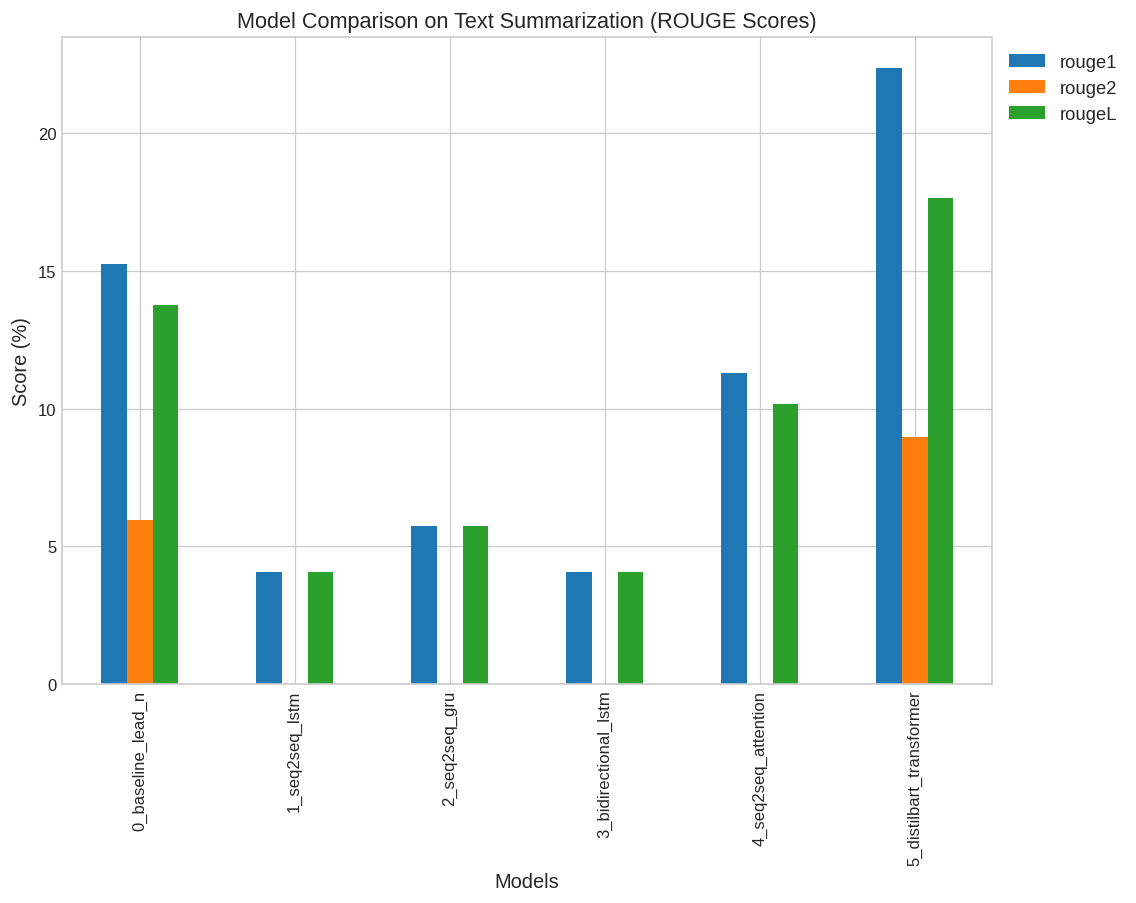

In [64]:
# Plot and compare all of the model results
import matplotlib.pyplot as plt

all_model_results.plot(kind="bar", figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0))
plt.title("Model Comparison on Text Summarization (ROUGE Scores)")
plt.xlabel("Models")
plt.ylabel("Score (%)")
plt.show()

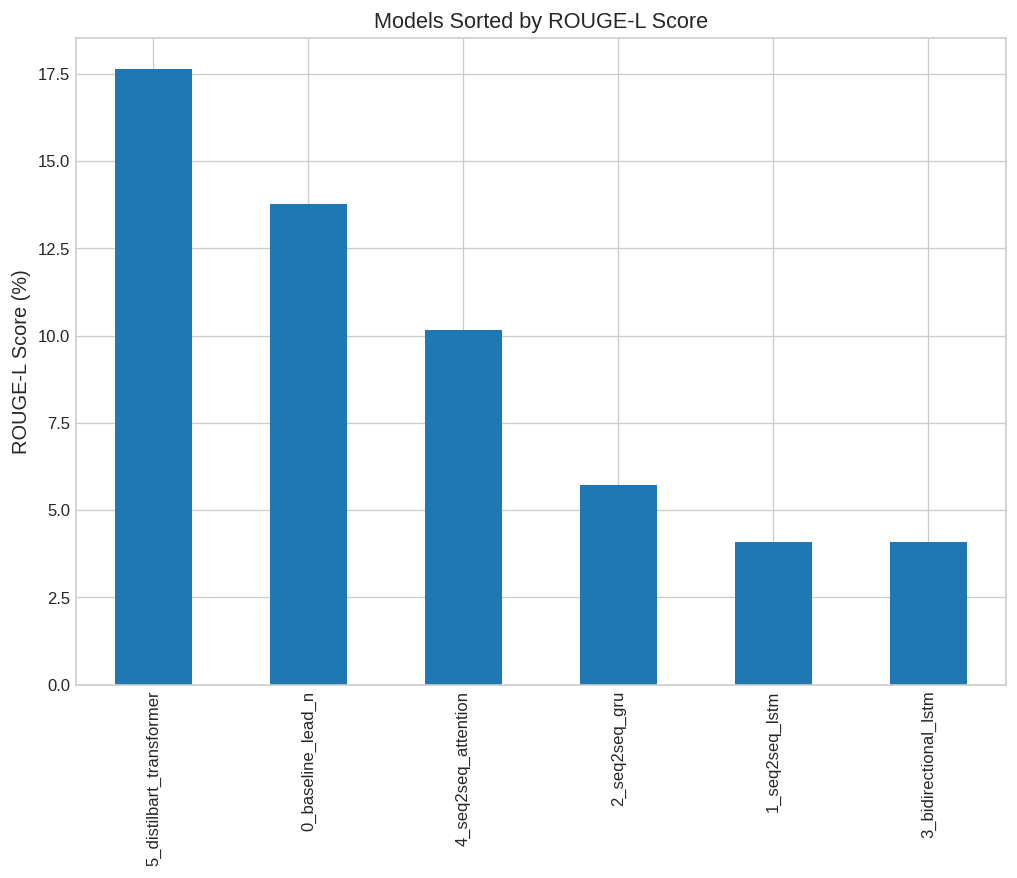

In [65]:
# Sort models by ROUGE-L score to find the best performing model
all_model_results.sort_values(by="rougeL", ascending=False)["rougeL"].plot(
    kind="bar", figsize=(10, 7)
)
plt.title("Models Sorted by ROUGE-L Score")
plt.ylabel("ROUGE-L Score (%)")
plt.show()

## Saving and Loading the Best Model

We can save our trained model / Hugging Face model directory to easily reload and verify performance.


In [66]:
# Save Model 5 (DistilBART) pretrained model and tokenizer
save_directory = "best_summarization_model"
hf_model.save_pretrained(save_directory)
hf_tokenizer.save_pretrained(save_directory)
print(f"Model and tokenizer saved to '{save_directory}'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to 'best_summarization_model'


In [67]:
# Load model and tokenizer into a new instance to verify performance
loaded_tokenizer = AutoTokenizer.from_pretrained(save_directory)
loaded_model = AutoModelForSeq2SeqLM.from_pretrained(save_directory).to(device)
loaded_model.eval()

# Verify loaded model on a sample dialogue
test_sample = "Hannah: Hey, are you free tomorrow evening?\nMark: Yes! What do you have in mind?\nHannah: Let's catch up over coffee around 6pm.\nMark: Sounds wonderful, see you tomorrow!"
inputs = loaded_tokenizer(test_sample, return_tensors="pt").to(device)
with torch.no_grad():
    out = loaded_model.generate(inputs["input_ids"], max_length=60)
print(
    "Loaded Model Summary:",
    loaded_tokenizer.decode(out[0], skip_special_tokens=True),
)

Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

Loaded Model Summary:  Mark says he's free to catch up with Hannah over coffee at 6pm . Hannah: Let's catch up over coffee around 6pm. Mark: Sounds wonderful, see you tomorrow! Hannah: 'Let's catch us over coffee over coffee' Mark: 'See you tomorrow. See


## Making Predictions on the Test Dataset

Now let's use our best model (Model 5: Pretrained DistilBART Transformer) to make predictions on the unseen test dataset and display 10 dialogue summaries alongside their ground truth references.


In [68]:
# Make predictions on a sample of the test dataset
test_sample_df = test_df.head(10).copy()
test_pred_summaries = generate_hf_summaries(
    test_sample_df["dialogue"].tolist(), batch_size=4
)

In [71]:
# Create a DataFrame to inspect test dialogues with generated predictions
test_results_df = test_sample_df.copy()
test_results_df["predicted_summary"] = test_pred_summaries

# Display results showing dialogue, reference summary, and generated summary
for i, row in test_results_df.head(1).iterrows():
    print(f"--- Test Sample #{i+1} ---")
    print(f"Dialogue:\n{row['dialogue']}\n")
    print(f"Ground Truth Summary:\n{row['summary']}\n")
    print(f"Model 5 Generated Summary:\n{row['predicted_summary']}\n")

--- Test Sample #1 ---
Dialogue:
Olafur: are we doing anything for New Year's Eve?
Nathalie: I was thinking about something classy, like opera or sth like that
Zoe: how much does it cost?
Olafur: opera is not for me
Nathalie: so what do you propose?
Nathalie: it's 100$ 
Olafur: I was thinking about partying somewhere
Nathalie: partying sounds fun, as long as it will be classy
Zoe: <file_link>
Zoe: Breakfast at Tiffany's party sounds classy
Olafur: <file_link> 
Olafur: is it classy enough?
Nathalie: :O
Nathalie: this club is AMAZING
Zoe: whoa
Nathalie: we'll going to Soho then
Olafur: we just need to hurry up and buy some tickets soon
Zoe: sure

Ground Truth Summary:
Nathalie, Olafur and Zoe are planning the New Year's Eve. Nathalie wants something classy. Olafur doesn't like opera. They want to go to the Breakfast at Tiffany's party in Soho.

Model 5 Generated Summary:
 Olafur: Are we doing anything for New Year's Eve? He was thinking about something classy, like opera or sth like that

In [ ]:
# Display test predictions in tabular format
test_results_df[["dialogue", "summary", "predicted_summary"]].head(10)